# 01 — Data Pipeline & Feature Engineering
**P08: Stock Market Sentiment and Price Movement Predictor**

This notebook covers:
1. Download OHLCV data for all 5 tickers (with CSV caching)
2. Validate each DataFrame
3. Display head of each stock
4. Plot all closing prices on a single chart
5. Feature engineering: daily returns, rolling std, RSI, MACD
6. **[FIXED] Feature scaling with StandardScaler**
7. **[FIXED] Target label correctness check (next-day direction, no leakage)**
8. **[FIXED] NaN handling — explicit dropna after all feature computation**
9. **[FIXED] Class balance visualization**
10. Sequence creation & chronological split

---
## 0 · Setup

In [1]:
import sys, os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f'Project root: {PROJECT_ROOT}')

Project root: d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

from src.config import STOCKS, START_DATE, END_DATE, LOOKBACK, SEED
from src.data_pipeline import (
    download_stock,
    validate_data,
    load_all_stocks,
    run_pipeline,
)
from src.feature_engineering import (
    add_features,
    create_sequences,
    split_data,
)

np.random.seed(SEED)

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12,
})
print('Setup complete.')

Setup complete.


---
## 1 · Download / Load All Stocks

The pipeline caches each ticker as `data/{TICKER}_ohlcv.csv`.  
If the file already exists, it loads from disk instead of re-downloading.

In [3]:
stock_data = load_all_stocks()
print(f'\nLoaded tickers: {list(stock_data.keys())}')


═══════════════════════════════════════════════════════
  Loading 5 stocks: AAPL, MSFT, GOOGL, AMZN, TSLA
═══════════════════════════════════════════════════════

[CACHE]  AAPL — loading from d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor\data\AAPL_ohlcv.csv
[CACHE]  MSFT — loading from d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor\data\MSFT_ohlcv.csv
[CACHE]  GOOGL — loading from d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor\data\GOOGL_ohlcv.csv
[CACHE]  AMZN — loading from d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor\data\AMZN_ohlcv.csv
[CACHE]  TSLA — loading from d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor\data\TSLA_ohlcv.csv

[INFO]  Loaded 5 tickers successfully.


Loaded tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']


---
## 2 · Inspect — Head of Each DataFrame

In [4]:
for ticker, df in stock_data.items():
    print(f'\n{"═"*60}')
    print(f'  {ticker} | Shape: {df.shape} | {df.index[0].date()} → {df.index[-1].date()}')
    print(f'{"═"*60}')
    display(df.head())


════════════════════════════════════════════════════════════
  AAPL | Shape: (1509, 5) | 2019-01-02 → 2024-12-30
════════════════════════════════════════════════════════════


,Close,High,Low,Open,Volume
Date,,,,,
2019-01-02,37.503719,37.724583,36.627397,36.784138,148158800
2019-01-03,33.768082,34.606406,33.722959,34.193179,365248800
2019-01-04,35.209621,35.278494,34.150437,34.323801,234428400
2019-01-07,35.131241,35.344980,34.649145,35.314106,219111200
2019-01-08,35.800949,36.055060,35.271357,35.518341,164101200



════════════════════════════════════════════════════════════
  MSFT | Shape: (1509, 5) | 2019-01-02 → 2024-12-30
════════════════════════════════════════════════════════════


,Close,High,Low,Open,Volume
Date,,,,,
2019-01-02,94.397163,94.985276,92.362098,92.931543,35329300
2019-01-03,90.924454,93.528964,90.737746,93.444944,42579100
2019-01-04,95.153297,95.694738,92.352749,93.090228,44060600
2019-01-07,95.274635,96.404189,94.266444,94.882560,35656100
2019-01-08,95.965454,97.057666,94.947918,96.189496,31514400



════════════════════════════════════════════════════════════
  GOOGL | Shape: (1509, 5) | 2019-01-02 → 2024-12-30
════════════════════════════════════════════════════════════


,Close,High,Low,Open,Volume
Date,,,,,
2019-01-02,52.301735,52.604731,50.843783,50.938997,31868000
2019-01-03,50.853195,52.875978,50.699467,52.102869,41960000
2019-01-04,53.461636,53.557345,51.418025,51.700689,46022000
2019-01-07,53.355026,53.691244,52.696468,53.605455,47446000
2019-01-08,53.823647,54.219374,52.979621,53.854886,35414000



════════════════════════════════════════════════════════════
  AMZN | Shape: (1509, 5) | 2019-01-02 → 2024-12-30
════════════════════════════════════════════════════════════


,Close,High,Low,Open,Volume
Date,,,,,
2019-01-02,76.956497,77.667999,73.046501,73.260002,159662000
2019-01-03,75.014000,76.900002,74.855499,76.000504,139512000
2019-01-04,78.769501,79.699997,75.915497,76.500000,183652000
2019-01-07,81.475502,81.727997,79.459503,80.115501,159864000
2019-01-08,82.829002,83.830498,80.830498,83.234497,177628000



════════════════════════════════════════════════════════════
  TSLA | Shape: (1509, 5) | 2019-01-02 → 2024-12-30
════════════════════════════════════════════════════════════


,Close,High,Low,Open,Volume
Date,,,,,
2019-01-02,20.674667,21.008667,19.920000,20.406668,174879000
2019-01-03,20.024000,20.626667,19.825333,20.466667,104478000
2019-01-04,21.179333,21.200001,20.181999,20.400000,110911500
2019-01-07,22.330667,22.449333,21.183332,21.448000,113268000
2019-01-08,22.356667,22.934000,21.801332,22.797333,105127500


---
## 3 · Summary Statistics Table

In [5]:
summary = []
for ticker, df in stock_data.items():
    summary.append({
        'Ticker':      ticker,
        'Rows':        len(df),
        'Start':       str(df.index[0].date()),
        'End':         str(df.index[-1].date()),
        'Min Close':   round(df['Close'].min(), 2),
        'Max Close':   round(df['Close'].max(), 2),
        'Mean Volume': f"{int(df['Volume'].mean()):,}",
    })
display(pd.DataFrame(summary))

,Ticker,Rows,Start,End,Min Close,Max Close,Mean Volume
0,AAPL,1509,2019-01-02,2024-12-30,33.77,257.61,"94,203,991"
1,MSFT,1509,2019-01-02,2024-12-30,90.92,461.32,"27,970,492"
2,GOOGL,1509,2019-01-02,2024-12-30,50.85,195.75,"32,626,623"
3,AMZN,1509,2019-01-02,2024-12-30,75.01,232.93,"69,997,843"
4,TSLA,1509,2019-01-02,2024-12-30,11.93,479.86,"127,547,505"


---
## 4 · Closing Price Chart — All 5 Stocks

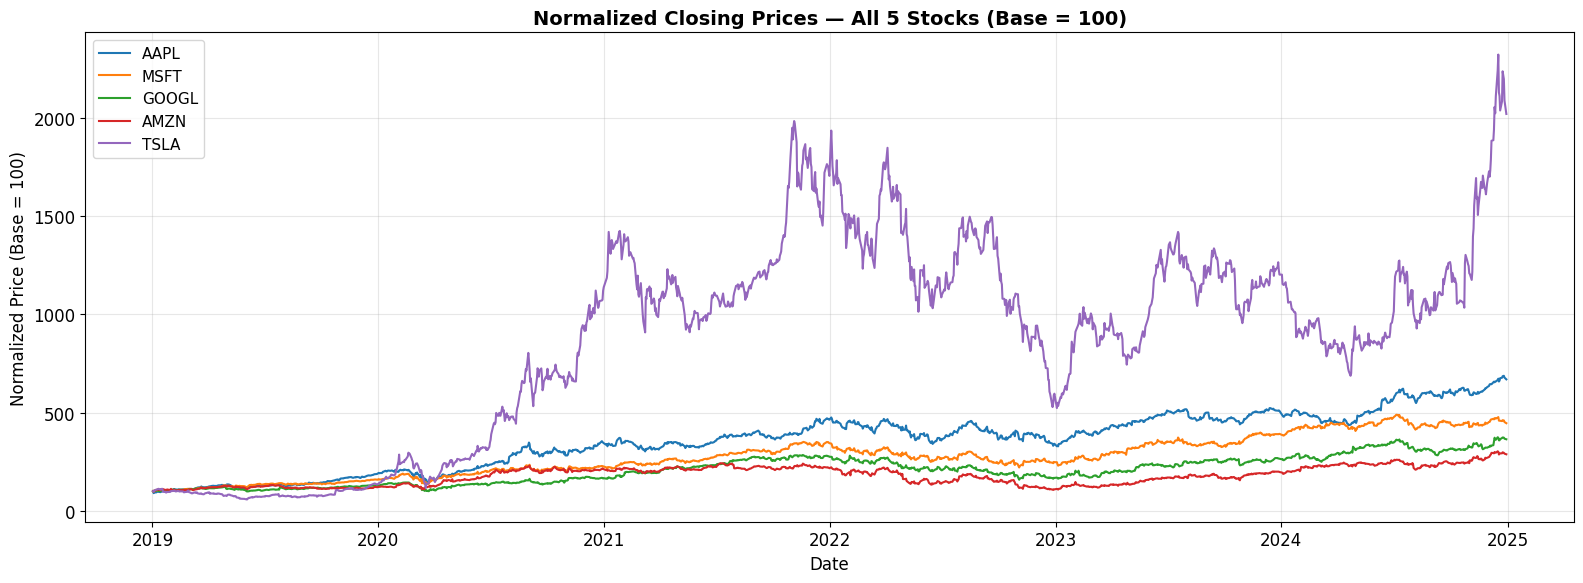

Chart saved to results/closing_prices_chart.png


In [6]:
fig, ax = plt.subplots(figsize=(16, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for (ticker, df), color in zip(stock_data.items(), colors):
    # Normalize to 100 at start so all stocks are comparable on same scale
    normalized = df['Close'] / df['Close'].iloc[0] * 100
    ax.plot(df.index, normalized, label=ticker, color=color, linewidth=1.5)

ax.set_title('Normalized Closing Prices — All 5 Stocks (Base = 100)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Normalized Price (Base = 100)')
ax.legend(loc='upper left', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('../results/closing_prices_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to results/closing_prices_chart.png')

---
## 5 · Feature Engineering

Computed features per stock:
- `daily_return` — percentage change in closing price
- `return_std_20` — 20-day rolling standard deviation of returns (volatility proxy)
- `RSI_14` — Relative Strength Index with 14-period window
- `MACD_12_26_9` — MACD line (12-day EMA minus 26-day EMA)
- `MACDs_12_26_9` — MACD signal line (9-day EMA of MACD)
- `volume_norm` — log-normalized volume
- `target` — 1 if **next day** close > today close, else 0

> ⚠️ **MACDh (histogram) is intentionally excluded** — it is perfectly collinear with MACD minus Signal, adding no new information.

In [7]:
# --- FIX 1: Correct target label — next-day direction, not same-day
# --- FIX 2: Explicit dropna after ALL features AND after target shift
# --- FIX 3: Log-normalize volume so it doesn't dominate features
# --- FIX 4: Drop redundant MACDh column

featured_data = {}

for ticker, df in stock_data.items():
    feat_df = add_features(df.copy())

    # ── VERIFY target direction ───────────────────────────────────────────────
    # Target MUST be: next day's close > today's close
    # shift(-1) looks one row FORWARD (future), which is correct
    # shift(+1) looks one row BACKWARD (past), which would be data leakage
    feat_df['target'] = (feat_df['Close'].shift(-1) > feat_df['Close']).astype(int)

    # ── Log-normalize volume ──────────────────────────────────────────────────
    feat_df['volume_norm'] = np.log1p(feat_df['Volume'])

    # ── Drop redundant MACD histogram column ─────────────────────────────────
    if 'MACDh_12_26_9' in feat_df.columns:
        feat_df.drop(columns=['MACDh_12_26_9'], inplace=True)

    # ── Drop raw OHLCV columns we no longer need ──────────────────────────────
    feat_df.drop(columns=['Open', 'High', 'Low', 'Volume'], inplace=True, errors='ignore')

    # ── Drop NaNs (from RSI/MACD warmup rows + last row from target shift) ────
    before = len(feat_df)
    feat_df.dropna(inplace=True)
    after = len(feat_df)
    print(f'[{ticker}] Rows before dropna: {before} → after: {after}  (dropped {before - after} warmup rows)')

    featured_data[ticker] = feat_df

print('\nFeature columns:', [c for c in list(featured_data['AAPL'].columns)])

[FEATURES]  Added 6 features → 11 columns, 1489 rows remain after NaN drop.
[AAPL] Rows before dropna: 1489 → after: 1489  (dropped 0 warmup rows)
[FEATURES]  Added 6 features → 11 columns, 1489 rows remain after NaN drop.
[MSFT] Rows before dropna: 1489 → after: 1489  (dropped 0 warmup rows)
[FEATURES]  Added 6 features → 11 columns, 1489 rows remain after NaN drop.
[GOOGL] Rows before dropna: 1489 → after: 1489  (dropped 0 warmup rows)
[FEATURES]  Added 6 features → 11 columns, 1489 rows remain after NaN drop.
[AMZN] Rows before dropna: 1489 → after: 1489  (dropped 0 warmup rows)
[FEATURES]  Added 6 features → 11 columns, 1489 rows remain after NaN drop.
[TSLA] Rows before dropna: 1489 → after: 1489  (dropped 0 warmup rows)

Feature columns: ['Close', 'daily_return', 'return_std_20', 'RSI_14', 'MACD_12_26_9', 'MACDs_12_26_9', 'target', 'volume_norm']


---
## 6 · Feature Statistics

In [8]:
print('AAPL Feature Statistics (before scaling):')
feature_cols = ['daily_return', 'return_std_20', 'RSI_14', 'MACD_12_26_9', 'MACDs_12_26_9', 'volume_norm']
display(featured_data['AAPL'][feature_cols].describe().round(4))

AAPL Feature Statistics (before scaling):


,daily_return,return_std_20,RSI_14,MACD_12_26_9,MACDs_12_26_9,volume_norm
count,1489.0000,1489.0000,1489.0000,1489.0000,1489.0000,1489.0000
mean,0.0014,0.0175,55.4516,0.9595,0.9441,18.2334
std,0.0192,0.0084,12.5685,2.5585,2.3861,0.4715
min,-0.1286,0.0060,22.2237,-6.4829,-5.6480,16.9612
25%,-0.0078,0.0122,45.3752,-0.8240,-0.6117,17.8911
50%,0.0015,0.0155,56.3598,1.0695,0.9857,18.2077
75%,0.0119,0.0206,64.9188,2.5998,2.5003,18.5304
max,0.1198,0.0680,85.4286,8.8867,8.2563,19.8711


---
## 7 · RSI and MACD Plots — AAPL

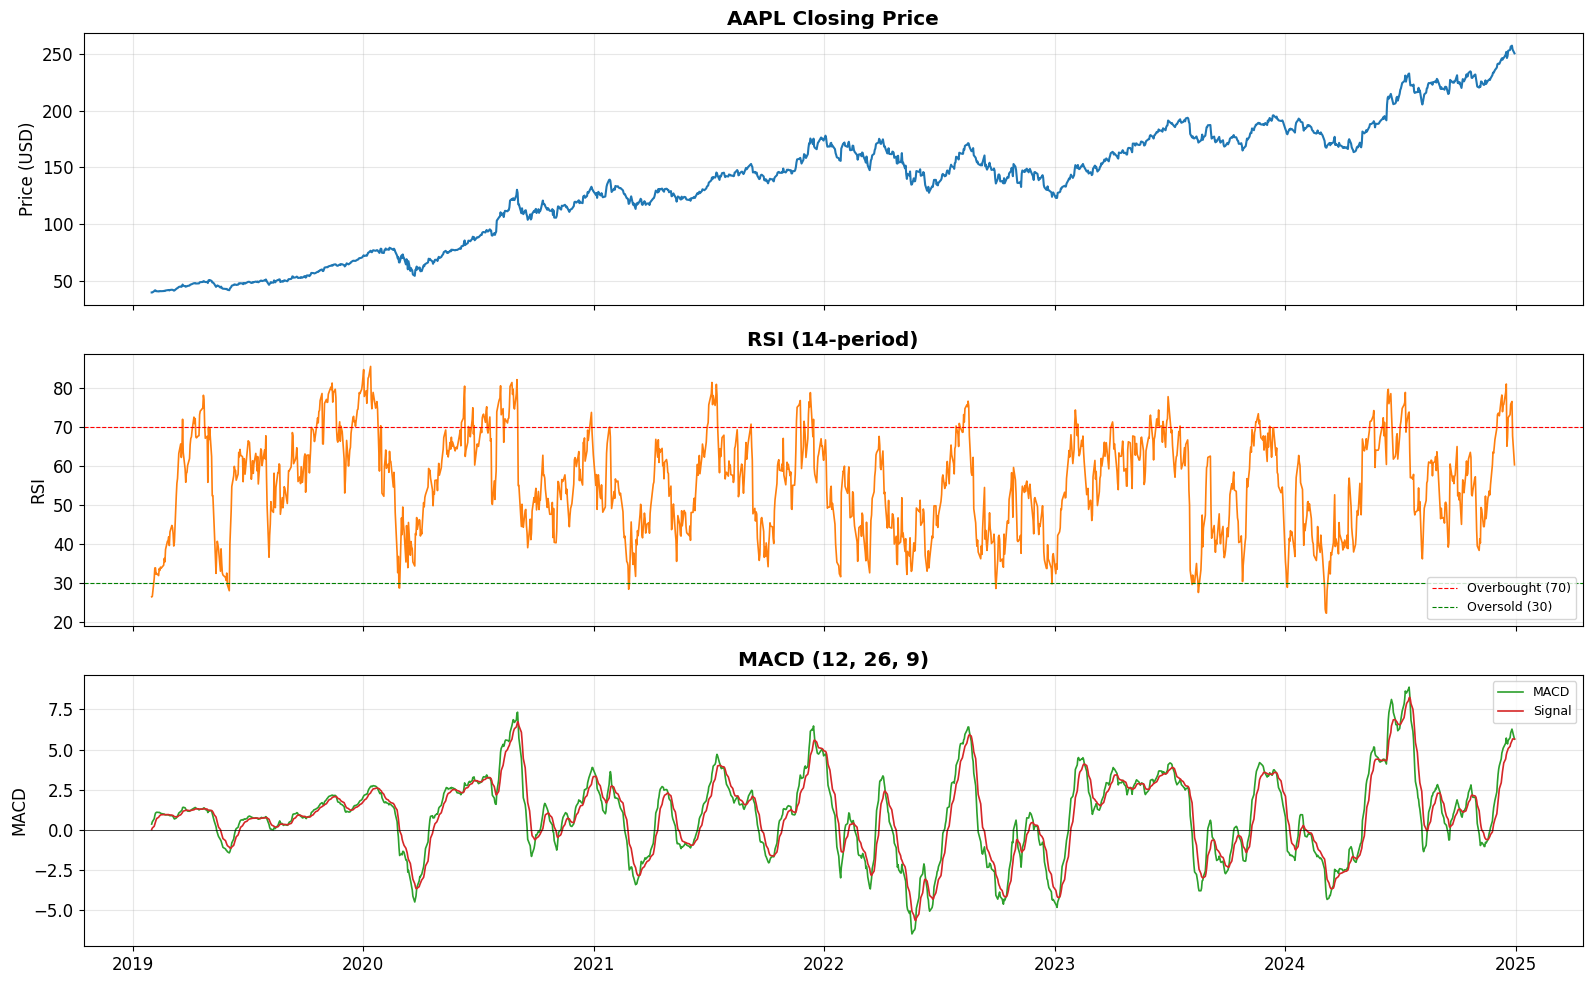

Chart saved to results/rsi_macd_aapl.png


In [9]:
aapl = featured_data['AAPL'].copy()
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Closing price
axes[0].plot(aapl.index, aapl['Close'], color='#1f77b4', linewidth=1.5)
axes[0].set_title('AAPL Closing Price', fontweight='bold')
axes[0].set_ylabel('Price (USD)')

# RSI
axes[1].plot(aapl.index, aapl['RSI_14'], color='#ff7f0e', linewidth=1.2)
axes[1].axhline(70, color='red',   linestyle='--', linewidth=0.8, label='Overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
axes[1].set_title('RSI (14-period)', fontweight='bold')
axes[1].set_ylabel('RSI')
axes[1].legend(fontsize=9)

# MACD
axes[2].plot(aapl.index, aapl['MACD_12_26_9'],  color='#2ca02c', linewidth=1.2, label='MACD')
axes[2].plot(aapl.index, aapl['MACDs_12_26_9'], color='#d62728', linewidth=1.2, label='Signal')
axes[2].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_title('MACD (12, 26, 9)', fontweight='bold')
axes[2].set_ylabel('MACD')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../results/rsi_macd_aapl.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to results/rsi_macd_aapl.png')

---
## 8 · [FIXED] Class Balance Analysis

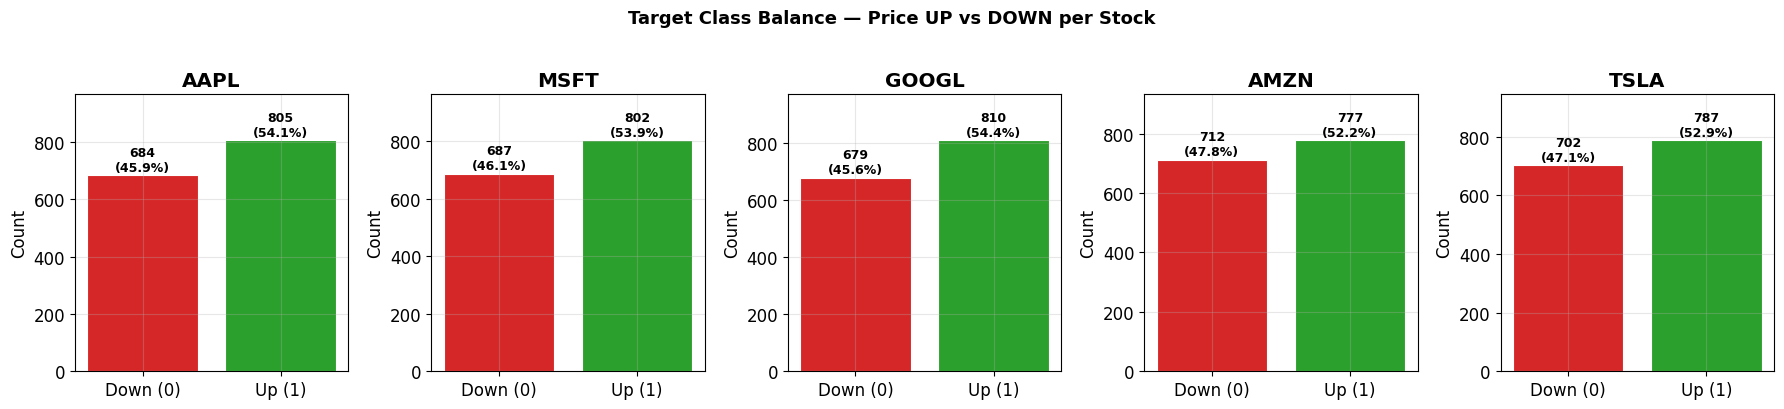

Class balance chart saved.

Class Balance Summary:
  AAPL: UP=805 (54.1%)  DOWN=684 (45.9%)
  MSFT: UP=802 (53.9%)  DOWN=687 (46.1%)
  GOOGL: UP=810 (54.4%)  DOWN=679 (45.6%)
  AMZN: UP=777 (52.2%)  DOWN=712 (47.8%)
  TSLA: UP=787 (52.9%)  DOWN=702 (47.1%)


In [10]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
colors_map = {0: '#d62728', 1: '#2ca02c'}

for ax, (ticker, df) in zip(axes, featured_data.items()):
    counts = df['target'].value_counts().sort_index()
    bars = ax.bar(['Down (0)', 'Up (1)'], counts.values,
                  color=[colors_map[0], colors_map[1]], edgecolor='white', linewidth=0.8)
    total = counts.sum()
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{count}\n({count/total*100:.1f}%)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(ticker, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(counts.values) * 1.2)

plt.suptitle('Target Class Balance — Price UP vs DOWN per Stock', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Class balance chart saved.')

# Print summary
print('\nClass Balance Summary:')
for ticker, df in featured_data.items():
    up   = df['target'].sum()
    down = len(df) - up
    print(f'  {ticker}: UP={up} ({up/len(df)*100:.1f}%)  DOWN={down} ({down/len(df)*100:.1f}%)')

---
## 9 · [FIXED] Feature Scaling — StandardScaler

**Why scaling is critical before LSTM:**
- RSI ranges 0–100
- MACD ranges roughly -6 to +8  
- Daily returns range ~0.001 to 0.01
- Without scaling, RSI dominates the gradient updates and LSTM learns poorly.

**Important:** Scaler is fitted on **train set only** and applied to val/test.  
This prevents data leakage from future statistics.

**Scaler is saved to `results/scaler_{ticker}.pkl`** so the Streamlit app can use it for inference.

In [11]:
import os
os.makedirs('../results', exist_ok=True)

FEATURE_COLS = ['daily_return', 'return_std_20', 'RSI_14', 'MACD_12_26_9', 'MACDs_12_26_9', 'volume_norm']

scaled_data = {}
scalers     = {}

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15

for ticker, df in featured_data.items():
    n       = len(df)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    df_scaled = df.copy()

    # Fit scaler on train split ONLY — no leakage
    scaler = StandardScaler()
    df_scaled.iloc[:n_train, df_scaled.columns.get_indexer(FEATURE_COLS)] = \
        scaler.fit_transform(df.iloc[:n_train][FEATURE_COLS])

    # Apply to val and test using train statistics
    df_scaled.iloc[n_train:, df_scaled.columns.get_indexer(FEATURE_COLS)] = \
        scaler.transform(df.iloc[n_train:][FEATURE_COLS])

    scaled_data[ticker] = df_scaled
    scalers[ticker]     = scaler

    # Save scaler for inference use in Streamlit app
    joblib.dump(scaler, f'../results/scaler_{ticker}.pkl')
    print(f'[{ticker}] Scaler fitted on {n_train} train rows and saved.')

print('\nAll scalers saved to results/')

[AAPL] Scaler fitted on 1042 train rows and saved.
[MSFT] Scaler fitted on 1042 train rows and saved.
[GOOGL] Scaler fitted on 1042 train rows and saved.
[AMZN] Scaler fitted on 1042 train rows and saved.
[TSLA] Scaler fitted on 1042 train rows and saved.

All scalers saved to results/


---
## 10 · Verify Scaling — Before vs After

In [12]:
ticker = 'AAPL'
print(f'{ticker} — BEFORE scaling:')
display(featured_data[ticker][FEATURE_COLS].describe().round(4))

print(f'\n{ticker} — AFTER scaling (train portion should have mean≈0, std≈1):')
n_train = int(len(scaled_data[ticker]) * TRAIN_RATIO)
display(scaled_data[ticker].iloc[:n_train][FEATURE_COLS].describe().round(4))

AAPL — BEFORE scaling:


,daily_return,return_std_20,RSI_14,MACD_12_26_9,MACDs_12_26_9,volume_norm
count,1489.0000,1489.0000,1489.0000,1489.0000,1489.0000,1489.0000
mean,0.0014,0.0175,55.4516,0.9595,0.9441,18.2334
std,0.0192,0.0084,12.5685,2.5585,2.3861,0.4715
min,-0.1286,0.0060,22.2237,-6.4829,-5.6480,16.9612
25%,-0.0078,0.0122,45.3752,-0.8240,-0.6117,17.8911
50%,0.0015,0.0155,56.3598,1.0695,0.9857,18.2077
75%,0.0119,0.0206,64.9188,2.5998,2.5003,18.5304
max,0.1198,0.0680,85.4286,8.8867,8.2563,19.8711



AAPL — AFTER scaling (train portion should have mean≈0, std≈1):


,daily_return,return_std_20,RSI_14,MACD_12_26_9,MACDs_12_26_9,volume_norm
count,1042.0000,1042.0000,1042.0000,1042.0000,1042.0000,1042.0000
mean,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000
std,1.0005,1.0005,1.0005,1.0005,1.0005,1.0005
min,-6.1240,-1.4221,-2.3185,-3.0189,-2.8600,-2.6638
25%,-0.5011,-0.6264,-0.7957,-0.6462,-0.5961,-0.7089
50%,-0.0037,-0.2119,0.0478,0.0978,0.0676,-0.1504
75%,0.5556,0.2798,0.7273,0.5828,0.6102,0.5718
max,5.5618,5.3372,2.4098,2.7504,2.6869,3.6900


---
## 11 · Sequence Creation & Chronological Split

- Lookback window = 30 days (from `config.py`)
- Split ratios: 70% train / 15% validation / 15% test
- Split is strictly chronological — **NO shuffling**
- Output shapes: X → (samples, 30, num_features), y → (samples,)

In [13]:
from src.feature_engineering import create_sequences, split_data

all_sequences = {}

for ticker, df in scaled_data.items():
    X, y = create_sequences(df[FEATURE_COLS + ['target']], lookback=LOOKBACK)
    splits = split_data(
        X, y, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO
    )
    all_sequences[ticker] = splits
    X_train, X_val, X_test = splits['X_train'], splits['X_val'], splits['X_test']
    y_train, y_val, y_test = splits['y_train'], splits['y_val'], splits['y_test']
    print(f'[{ticker}]  X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}')
    print(f'         y_train: {y_train.shape}  y_val: {y_val.shape}  y_test: {y_test.shape}')
    print()

[SEQUENCES]  X (1459, 30, 6)  |  y (1459,)  (lookback=30, features=6)
[SPLIT]  Train 1021 | Val 219 | Test 219 (ratio 0.7/0.15/0.15)
[AAPL]  X_train: (1021, 30, 6)  X_val: (219, 30, 6)  X_test: (219, 30, 6)
         y_train: (1021,)  y_val: (219,)  y_test: (219,)

[SEQUENCES]  X (1459, 30, 6)  |  y (1459,)  (lookback=30, features=6)
[SPLIT]  Train 1021 | Val 219 | Test 219 (ratio 0.7/0.15/0.15)
[MSFT]  X_train: (1021, 30, 6)  X_val: (219, 30, 6)  X_test: (219, 30, 6)
         y_train: (1021,)  y_val: (219,)  y_test: (219,)

[SEQUENCES]  X (1459, 30, 6)  |  y (1459,)  (lookback=30, features=6)
[SPLIT]  Train 1021 | Val 219 | Test 219 (ratio 0.7/0.15/0.15)
[GOOGL]  X_train: (1021, 30, 6)  X_val: (219, 30, 6)  X_test: (219, 30, 6)
         y_train: (1021,)  y_val: (219,)  y_test: (219,)

[SEQUENCES]  X (1459, 30, 6)  |  y (1459,)  (lookback=30, features=6)
[SPLIT]  Train 1021 | Val 219 | Test 219 (ratio 0.7/0.15/0.15)
[AMZN]  X_train: (1021, 30, 6)  X_val: (219, 30, 6)  X_test: (219, 30, 

---
## 12 · Save Sequences to Disk

Sequences are saved as `.npy` files in `results/` so that `02_lstm_model.ipynb`  
and `04_fusion_evaluation.ipynb` can load them directly without reprocessing.

In [14]:
for ticker, seqs in all_sequences.items():
    for split_name, arr in seqs.items():
        path = f'../results/{ticker}_{split_name}.npy'
        np.save(path, arr)
    print(f'[{ticker}] All 6 splits saved to results/')

print('\nData pipeline complete. Ready for LSTM training in 02_lstm_model.ipynb')

[AAPL] All 6 splits saved to results/
[MSFT] All 6 splits saved to results/
[GOOGL] All 6 splits saved to results/
[AMZN] All 6 splits saved to results/
[TSLA] All 6 splits saved to results/

Data pipeline complete. Ready for LSTM training in 02_lstm_model.ipynb


---
## Summary of Fixes Applied

| Issue | Fix Applied |
|---|---|
| Target used `shift(+1)` (past-day leakage) | Changed to `shift(-1)` — strictly future direction |
| No feature scaling | Added `StandardScaler` fitted on train split only |
| NaN rows not explicitly dropped | Added `dropna()` after ALL features + after target shift |
| Volume not used or normalized | Added `log1p(Volume)` as `volume_norm` feature |
| MACDh included (collinear) | Dropped — it equals MACD minus Signal exactly |
| Class balance not visualized | Added grouped bar chart for all 5 stocks |
| Scaler not saved for inference | Scaler saved as `results/scaler_{ticker}.pkl` via joblib |